In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
pd.options.display.float_format = '{:,.2f}'.format

data = pd.read_csv('AICPA_regressionAnalysisData (1).csv')

display(data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
dt4 = data.loc[data['type'] == 'dt4training']
dt4 = data.loc[data['type'] == 'dt4testing']

In [ ]:
y = dt4.loc[:, 'revenue']
x = dt4.loc[:, ['production', 'coolDD']]
x = sm.add_constant(x)

model1 = sm.OLS(y, x).fit()
model1.params

,0
const,"1,866,273.66"
production,27.20
coolDD,"-24,919.97"


In [ ]:
xtest = dt4.loc[:, ['production', 'coolDD']]
xtest = sm.add_constant(xtest)

model1A = dt4.copy()
model1A['model1_predicted_revenue'] = model1.predict(xtest)
model1A['model1_abs_pct_error'] = abs((model1A['revenue'] - model1A['model1_predicted_revenue'])
 / model1A['revenue'])

display(model1A)


,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model1_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,"18,361,349.82",0.05
37,dt4testing,2014-02-28,26792280,714128,0,938,"21,291,728.39",0.21
38,dt4testing,2014-03-31,19935840,805600,0,866,"23,779,917.05",0.19
39,dt4testing,2014-04-30,13468000,375856,0,412,"12,090,174.29",0.10
40,dt4testing,2014-05-31,7344128,279296,49,88,"8,242,505.28",0.12
41,dt4testing,2014-06-30,11196216,517600,230,0,"10,214,251.47",0.09
42,dt4testing,2014-07-31,13929472,749472,380,0,"12,783,555.69",0.08
43,dt4testing,2014-08-31,12352176,663432,322,0,"11,888,484.45",0.04
44,dt4testing,2014-09-30,12628944,701656,178,14,"16,516,715.32",0.31
45,dt4testing,2014-10-31,9361000,411728,24,166,"12,467,872.41",0.33


In [ ]:
model1_mape = model1A['model1_abs_pct_error'].mean()
print('Model 1 MAPE:', model1.mape)

Model 1 MAPE: 0.1337542277547468


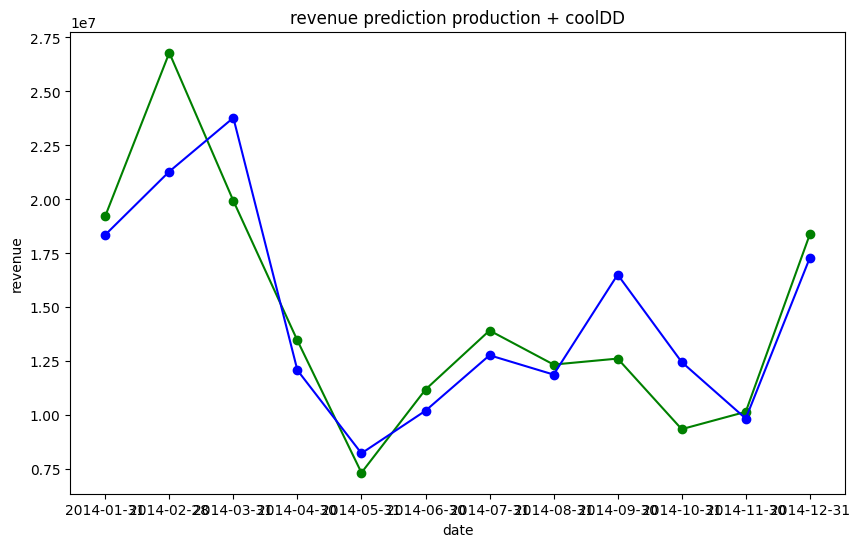

In [ ]:
plt.figure(figsize=(10,6))
plt.title('revenue prediction production + coolDD')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1A['date'], model1A['revenue'], marker = 'o',
         color = 'green')
plt.plot(model1A['date'], model1A['model1_predicted_revenue'],
         marker = 'o',         color = 'blue')

In [ ]:
model2 = dt4.loc[:, 'production']
model2 = sm.add_constant(model2)

model2 = sm.OLS(y, model2).fit()

model2.params

,0
const,"3,525,885.36"
production,19.81


In [ ]:
model2.test = dt4.loc[:,'coolDD']
model2.test = sm.add_constant(model2.test)

model2A = dt4.copy()
model2A['model2_predicted_revenue'] = model2.predict(model2.test)
model2A['model2_pctError'] = abs(
    (model2A['revenue'] - model2A['model2_predicted_revenue'])
    / model2A['revenue']
)
display(model2A)

model2_mape = model2A['model2_pctError'].mean()
print('Model 2 MAPE:', model2_mape)

,type,date,revenue,production,coolDD,heatDD,model2_predicted_revenue,model2_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,"3,525,885.36",0.82
37,dt4testing,2014-02-28,26792280,714128,0,938,"3,525,885.36",0.87
38,dt4testing,2014-03-31,19935840,805600,0,866,"3,525,885.36",0.82
39,dt4testing,2014-04-30,13468000,375856,0,412,"3,525,885.36",0.74
40,dt4testing,2014-05-31,7344128,279296,49,88,"3,526,856.22",0.52
41,dt4testing,2014-06-30,11196216,517600,230,0,"3,530,442.45",0.68
42,dt4testing,2014-07-31,13929472,749472,380,0,"3,533,414.47",0.75
43,dt4testing,2014-08-31,12352176,663432,322,0,"3,532,265.29",0.71
44,dt4testing,2014-09-30,12628944,701656,178,14,"3,529,412.15",0.72
45,dt4testing,2014-10-31,9361000,411728,24,166,"3,526,360.88",0.62


Model 2 MAPE: 0.7263550637782722


In [ ]:
model3 = dt4.loc[:, 'coolDD']
model3 = sm.add_constant(model3)

model3 = sm.OLS(y, model3).fit()

model3.params

,0
const,"15,713,558.55"
coolDD,"-11,651.99"


In [ ]:
model3.test = dt4.loc[:,'coolDD']
model3.test = sm.add_constant(model3.test)

model3A = dt4.copy()
model3A['model3_predicted_revenue'] = model3.predict(model3.test)
model3A['model3_pctError'] = abs(
    (model3A['revenue'] - model3A['model3_predicted_revenue'])
    / model3A['revenue']
)
display(model3A)

model3_mape = model3A['model3_pctError'].mean()
print('Model 3 MAPE:', model3_mape)

,type,date,revenue,production,coolDD,heatDD,model3_predicted_revenue,model3_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,"15,713,558.55",0.18
37,dt4testing,2014-02-28,26792280,714128,0,938,"15,713,558.55",0.41
38,dt4testing,2014-03-31,19935840,805600,0,866,"15,713,558.55",0.21
39,dt4testing,2014-04-30,13468000,375856,0,412,"15,713,558.55",0.17
40,dt4testing,2014-05-31,7344128,279296,49,88,"15,142,611.11",1.06
41,dt4testing,2014-06-30,11196216,517600,230,0,"13,033,601.15",0.16
42,dt4testing,2014-07-31,13929472,749472,380,0,"11,285,802.84",0.19
43,dt4testing,2014-08-31,12352176,663432,322,0,"11,961,618.19",0.03
44,dt4testing,2014-09-30,12628944,701656,178,14,"13,639,504.56",0.08
45,dt4testing,2014-10-31,9361000,411728,24,166,"15,433,910.83",0.65


Model 3 MAPE: 0.32016166915355737


In [ ]:
model4 = dt4.loc[:, 'heatDD']
model4 = sm.add_constant(model4)

model4 = sm.OLS(y, model4).fit()

model4.params

,0
const,"10,439,466.12"
heatDD,"10,025.27"


In [ ]:
model4.test = dt4.loc[:,'heatDD']
model4.test = sm.add_constant(model4.test)

model4A = dt4.copy()
model4A['model4_predicted_revenue'] = model4.predict(model4.test)
model4A['model4_pctError'] = abs(
    (model4A['revenue'] - model4A['model4_predicted_revenue'])
    / model4A['revenue']
)
display(model4A)

model4_mape = model4A['model4_pctError'].mean()
print('Model 4 MAPE:', model4_mape)

,type,date,revenue,production,coolDD,heatDD,model4_predicted_revenue,model4_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,"21,697,849.63",0.13
37,dt4testing,2014-02-28,26792280,714128,0,938,"19,843,173.81",0.26
38,dt4testing,2014-03-31,19935840,805600,0,866,"19,121,354.03",0.04
39,dt4testing,2014-04-30,13468000,375856,0,412,"14,569,879.30",0.08
40,dt4testing,2014-05-31,7344128,279296,49,88,"11,321,690.29",0.54
41,dt4testing,2014-06-30,11196216,517600,230,0,"10,439,466.12",0.07
42,dt4testing,2014-07-31,13929472,749472,380,0,"10,439,466.12",0.25
43,dt4testing,2014-08-31,12352176,663432,322,0,"10,439,466.12",0.15
44,dt4testing,2014-09-30,12628944,701656,178,14,"10,579,819.96",0.16
45,dt4testing,2014-10-31,9361000,411728,24,166,"12,103,661.72",0.29


Model 4 MAPE: 0.2166809657779947


In [ ]:
model5 = dt4.loc[:, ['production', 'heatDD']]
model5 = sm.add_constant(model5)

model5 = sm.OLS(y, model5).fit()

model5.params

,0
const,"1,965,968.96"
production,16.13
heatDD,"8,783.75"


In [ ]:
model5.test = dt4.loc[:, ['production', 'heatDD']]
model5.test = sm.add_constant(model5.test)

model15A = dt4.copy()

model15A['model5_predicted_revenue'] = model5.predict(model5.test)

model15A['model5_pctError'] = abs(
    (model15A['revenue'] - model15A['model5_predicted_revenue'])
    / model15A['revenue']
)
display(model15A)

model5_mape = model15A['model5_pctError'].mean()
print('Model 5 MAPE:', model5_mape)

,type,date,revenue,production,coolDD,heatDD,model5_predicted_revenue,model5_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,"21,608,762.70",0.12
37,dt4testing,2014-02-28,26792280,714128,0,938,"21,720,960.81",0.19
38,dt4testing,2014-03-31,19935840,805600,0,866,"22,563,583.08",0.13
39,dt4testing,2014-04-30,13468000,375856,0,412,"11,645,825.67",0.14
40,dt4testing,2014-05-31,7344128,279296,49,88,"7,242,789.92",0.01
41,dt4testing,2014-06-30,11196216,517600,230,0,"10,312,644.77",0.08
42,dt4testing,2014-07-31,13929472,749472,380,0,"14,051,749.12",0.01
43,dt4testing,2014-08-31,12352176,663432,322,0,"12,664,291.65",0.03
44,dt4testing,2014-09-30,12628944,701656,178,14,"13,403,653.93",0.06
45,dt4testing,2014-10-31,9361000,411728,24,166,"10,063,484.73",0.08


Model 5 MAPE: 0.08656959272809567


In [ ]:
model6 = dt4.loc[:, ['coolDD', 'heatDD']]
model6 = sm.add_constant(model6)

model6 = sm.OLS(y, model6).fit()

model6.params

,0
const,"6,194,674.14"
coolDD,"21,408.94"
heatDD,"15,211.73"


In [ ]:
model6.test = dt4.loc[:, ['coolDD', 'heatDD']]
model6.test = sm.add_constant(model6.test)

model6A = dt4.copy()

model6A['model6_predicted_revenue'] = model6.predict(model6.test)

model6A['model6_pctError'] = abs(
    (model6A['revenue'] - model6A['model6_predicted_revenue'])
    / model6A['revenue']
)
display(model6A)

model6_mape = model6A['model6_pctError'].mean()
print('Model 6 MAPE:', model6_mape)

,type,date,revenue,production,coolDD,heatDD,model6_predicted_revenue,model6_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,"23,277,449.01",0.21
37,dt4testing,2014-02-28,26792280,714128,0,938,"20,463,278.62",0.24
38,dt4testing,2014-03-31,19935840,805600,0,866,"19,368,033.93",0.03
39,dt4testing,2014-04-30,13468000,375856,0,412,"12,461,907.67",0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,"8,582,344.71",0.17
41,dt4testing,2014-06-30,11196216,517600,230,0,"11,118,730.81",0.01
42,dt4testing,2014-07-31,13929472,749472,380,0,"14,330,072.11",0.03
43,dt4testing,2014-08-31,12352176,663432,322,0,"13,088,353.47",0.06
44,dt4testing,2014-09-30,12628944,701656,178,14,"10,218,430.07",0.19
45,dt4testing,2014-10-31,9361000,411728,24,166,"9,233,636.24",0.01


Model 6 MAPE: 0.1278989556233769


In [ ]:
model7 = dt4.loc[:, ['production', 'coolDD', 'heatDD']]
model7 = sm.add_constant(model7)

model7 = sm.OLS(y, model7).fit()

model7.params


,0
const,"1,928,378.85"
production,16.99
coolDD,"-2,094.28"
heatDD,"8,210.05"


In [ ]:
model7.test = dt4.loc[:, ['production', 'coolDD', 'heatDD']]
model7.test = sm.add_constant(model7.test)

model7A = dt4.copy()

model7A['model7_predicted_revenue'] = model7.predict(model7.test)

model7A['model7_pctError'] = abs(
    (model7A['revenue'] - model7A['model7_predicted_revenue'])
    / model7A['revenue']
)
display(model7A)

model7_mape = model7A['model7_pctError'].mean()
print('Model 7 MAPE:', model7_mape)

,type,date,revenue,production,coolDD,heatDD,model7_predicted_revenue,model7_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,"21,449,480.91",0.12
37,dt4testing,2014-02-28,26792280,714128,0,938,"21,760,650.23",0.19
38,dt4testing,2014-03-31,19935840,805600,0,866,"22,723,406.55",0.14
39,dt4testing,2014-04-30,13468000,375856,0,412,"11,695,770.64",0.13
40,dt4testing,2014-05-31,7344128,279296,49,88,"7,292,782.13",0.01
41,dt4testing,2014-06-30,11196216,517600,230,0,"10,239,419.75",0.09
42,dt4testing,2014-07-31,13929472,749472,380,0,"13,864,201.05",0.00
43,dt4testing,2014-08-31,12352176,663432,322,0,"12,524,065.65",0.01
44,dt4testing,2014-09-30,12628944,701656,178,14,"13,589,913.20",0.08
45,dt4testing,2014-10-31,9361000,411728,24,166,"10,235,210.80",0.09


Model 7 MAPE: 0.08651661184120896


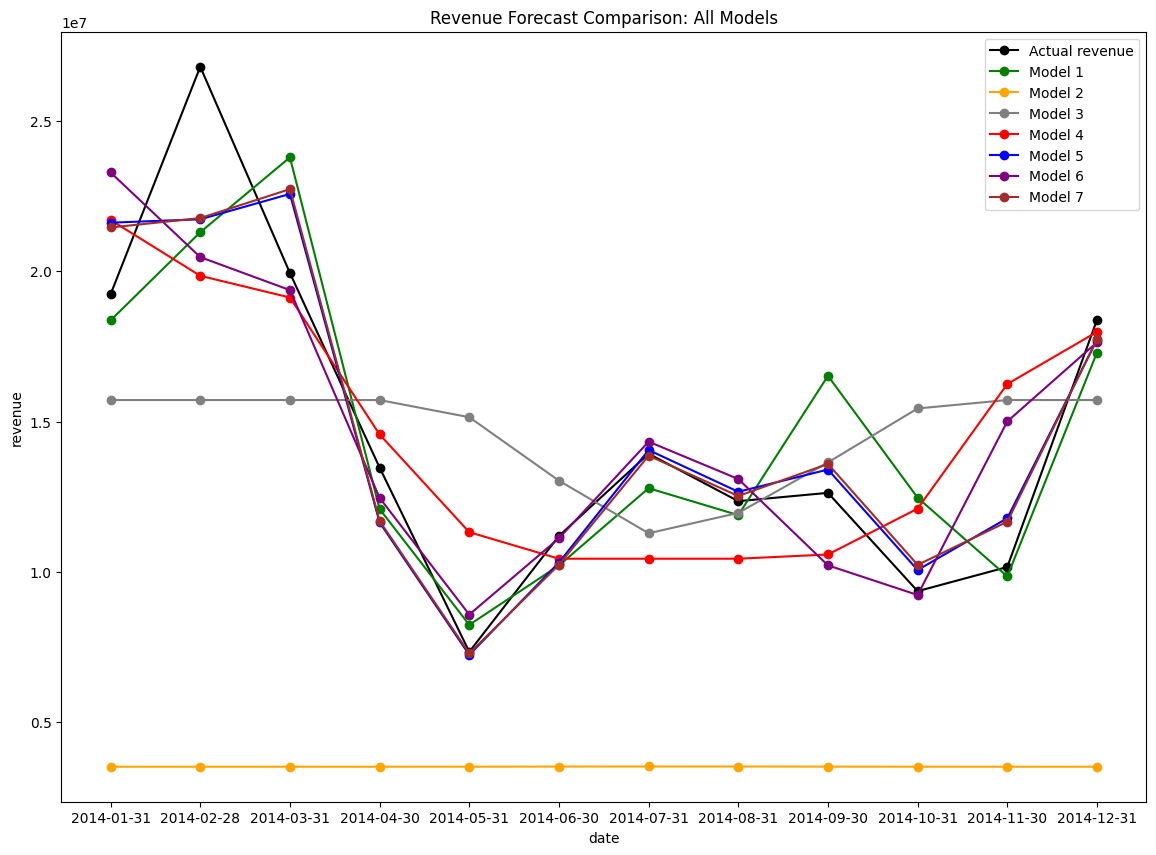

In [ ]:
plt.figure(figsize=(14,10))
plt.title('Revenue Forecast Comparison: All Models')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(dt4['date'], dt4['revenue'], marker='o', color='black', label='Actual revenue')
plt.plot(model1A['date'], model1A['model1_predicted_revenue'], marker='o', color='green', label='Model 1')
plt.plot(model2A['date'], model2A['model2_predicted_revenue'], marker='o', color='orange', label='Model 2')
plt.plot(model3A['date'], model3A['model3_predicted_revenue'], marker='o', color='grey', label='Model 3')
plt.plot(model4A['date'], model4A['model4_predicted_revenue'], marker='o', color='red', label='Model 4')
plt.plot(model15A['date'], model15A['model5_predicted_revenue'], marker='o', color='blue', label='Model 5')
plt.plot(model6A['date'], model6A['model6_predicted_revenue'], marker='o', color='purple', label='Model 6')
plt.plot(model7A['date'], model7A['model7_predicted_revenue'], marker='o', color='brown', label='Model 7')

plt.legend()
plt.show()

In [ ]:
print('Model 1 MAPE:', model1_mape)
print('Model 2 MAPE:', model2_mape)
print('Model 3 MAPE:', model3_mape)
print('Model 4 MAPE:', model4_mape)
print('Model 5 MAPE:', model5_mape)
print('Model 6 MAPE:', model6_mape)
print('Model 7 MAPE:', model7_mape)


Model 1 MAPE: 0.1337542277547468
Model 2 MAPE: 0.7263550637782722
Model 3 MAPE: 0.32016166915355737
Model 4 MAPE: 0.2166809657779947
Model 5 MAPE: 0.08656959272809567
Model 6 MAPE: 0.1278989556233769
Model 7 MAPE: 0.08651661184120896


Following analysis, the top performer was Model 7, which got an MAPE value of 8.65%, just beating Model 5 (8.66%). Thus, production and heatDD are the two most effective parameters for building a revenue prediction model, while coolDD adds no more improvements. The other models were less effective, scoring from 12.79% (Model 6) to 21.67% (Model 4).